In [3]:
%pip install pygad

Note: you may need to restart the kernel to use updated packages.


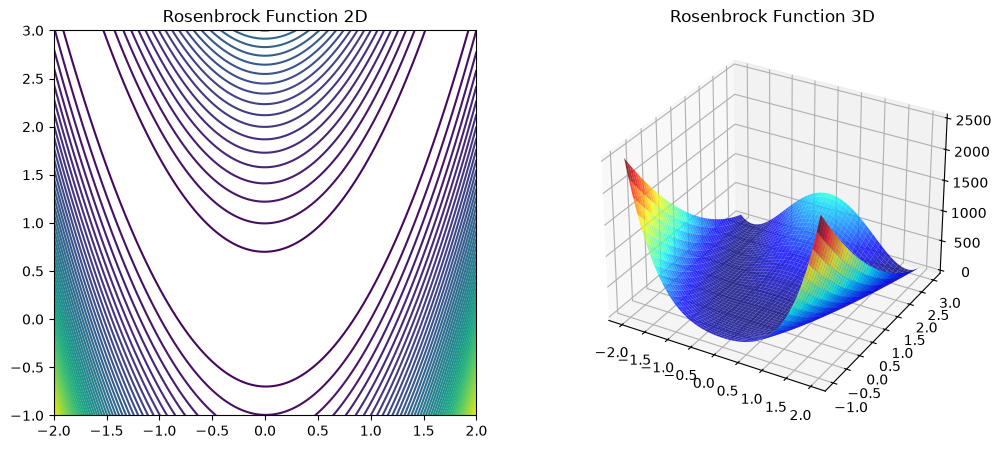

Initial guess [1, 2], Result: [0.99999649 0.99999304], Value: 1.2746220879976556e-11, Success: False, Iterations: 21, Time: 0.0122 sec
Initial guess [2, 2], Result: [0.99999565 0.99999129], Value: 1.8932767409827346e-11, Success: True, Iterations: 30, Time: 0.0107 sec
Initial guess [0, 0], Result: [0.99999467 0.99998932], Value: 2.8440052847381483e-11, Success: True, Iterations: 19, Time: 0.0042 sec


c:\Users\nivetha s\.conda\envs\mude-base\Lib\site-packages\pygad\utils\validation.py:966: UserWarning: The percentage of genes to mutate (mutation_percent_genes=10) resulted in selecting (0) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).
If you do not want to mutate any gene, please set mutation_type=None.
  warnings.warn(


PyGAD initial guess [1, 2], Solution: [1.01017661 1.02148598], Value: rosenbrock(solution), iterations: 2000, Time: 0.9177 sec
PyGAD initial guess [2, 2], Solution: [1.01090268 1.02283002], Value: rosenbrock(solution), iterations: 2000, Time: 0.9719 sec
PyGAD initial guess [0, 0], Solution: [0.97907595 0.95821287], Value: rosenbrock(solution), iterations: 2000, Time: 0.8499 sec


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

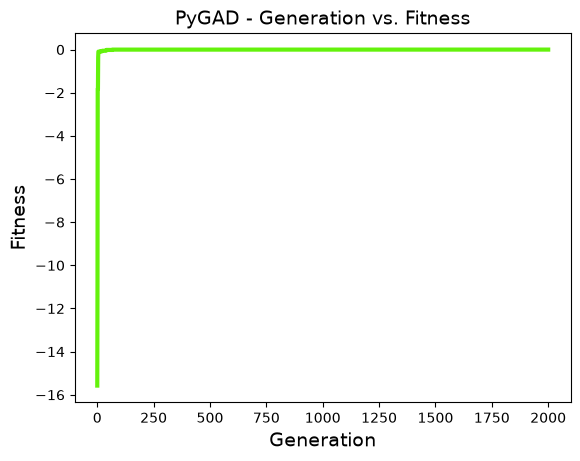

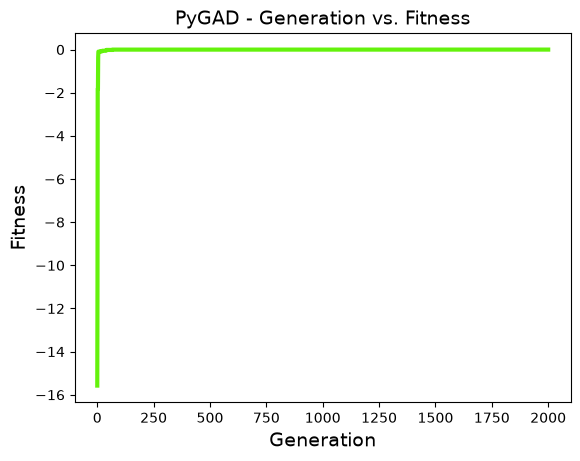

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
import pygad

# Define Rosenbrock function
def rosenbrock(x):
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

# 2D & 3D plots
x_range = np.linspace(-2, 2, 400)
y_range = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = rosenbrock([X, Y])

fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121)
cp = ax1.contour(X, Y, Z, levels=50)
ax1.set_title("Rosenbrock Function 2D")
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)
ax2.set_title("Rosenbrock Function 3D")
plt.show()

elapsed_time = []
# Scipy Optimization
init_guesses = [[1, 2], [2, 2], [0, 0]]
for guess in init_guesses:
    start_time = time.perf_counter()   # start timer
    result = minimize(rosenbrock, guess, method='BFGS')
    end_time = time.perf_counter()     # end timer
    elapsed_time = end_time - start_time
    print(f"Initial guess {guess}, Result: {result.x}, Value: {result.fun}, Success: {result.success}, Iterations: {result.nit}, Time: {elapsed_time:.4f} sec")

# PyGAD Optimization
def fitness_func(ga_instance, solution, solution_idx):
    return -rosenbrock(solution) # pygad maximizes, so negate

elapsed_time = []
for guess in init_guesses:
    start_time = time.perf_counter()   # start timer
    ga_instance = pygad.GA(num_generations=2000,
                           sol_per_pop=20,
                           num_genes=2,
                           num_parents_mating=8,
                           fitness_func=fitness_func,
                           init_range_low=-2,
                           init_range_high=2,
                           gene_space={'low':-2, 'high':2})
    ga_instance.run()
    solution, solution_fitness, _ = ga_instance.best_solution()
    iters = ga_instance.generations_completed
    end_time = time.perf_counter()     # end timer
    elapsed_time = end_time - start_time
    print(f"PyGAD initial guess {guess}, Solution: {solution}, Value: rosenbrock(solution), iterations: {iters}, Time: {elapsed_time:.4f} sec")
    plt.figure(figsize=(8, 6))
ga_instance.plot_fitness()

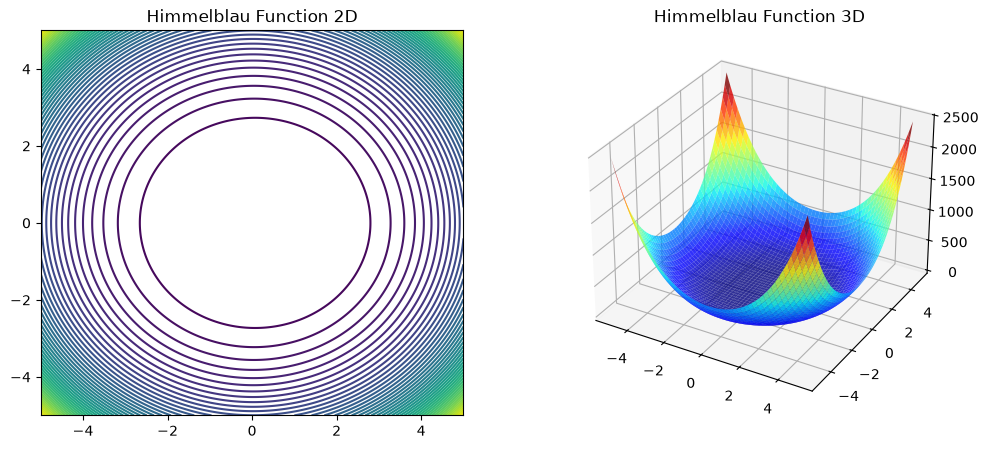

Initial guess [0, 0], Result: [ 9.99999966e-01 -1.64047755e-08], Value: 5.950412924404877e-15, Success: True, Iterations: 3, Time: 0.0044 sec
Initial guess [-4, 4], Result: [1.00000002e+00 5.98350441e-08], Value: 5.219780066839598e-15, Success: True, Iterations: 18, Time: 0.0047 sec
Initial guess [4, 0], Result: [1.00000001e+00 3.95264636e-07], Value: 1.5669751973834185e-13, Success: True, Iterations: 10, Time: 0.0019 sec
PyGAD initial guess [0, 0], Solution: [ 0.969953   -0.00306491], Value: 0.004414698960866402, iterations: 300, Time: 0.3305 sec
PyGAD initial guess [-4, 4], Solution: [ 1.00754413 -0.00231755], Value: 0.0002918239193693271, iterations: 300, Time: 0.2008 sec
PyGAD initial guess [4, 0], Solution: [ 1.00364846 -0.0032486 ], Value: 7.745852874123923e-05, iterations: 300, Time: 0.2005 sec


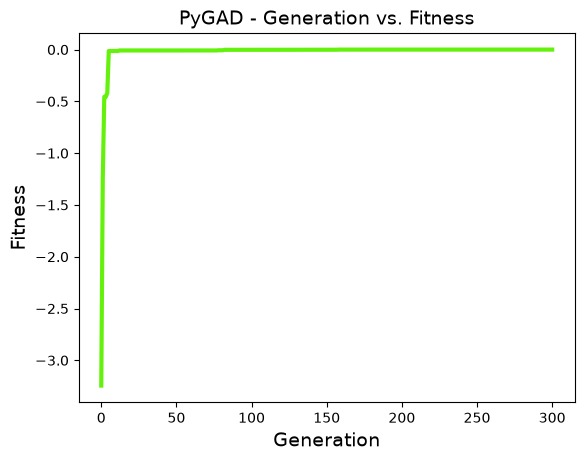

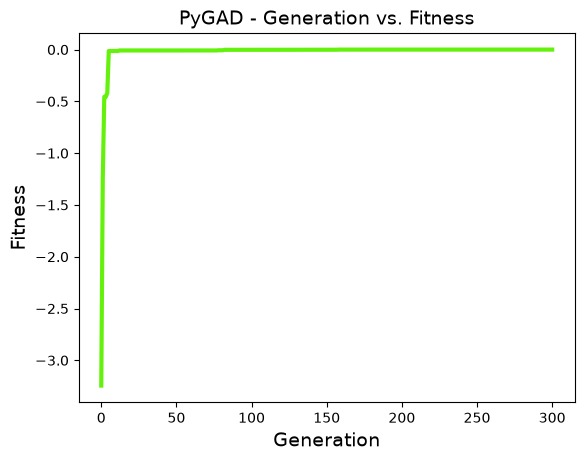

In [13]:
import numpy as np
import time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
import pygad

def himmelblau(x):
    x = np.asarray(x) # Convert to numpy array
    return (x[0]**2 + x[1]**2 - 1)**2 + (x[0] - 1)**2 + (x[1])**2

# 2D & 3D plots
x_range = np.linspace(-5, 5, 400)
y_range = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = himmelblau([X, Y])

fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121)
cp = ax1.contour(X, Y, Z, levels=50)
ax1.set_title("Himmelblau Function 2D")
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)
ax2.set_title("Himmelblau Function 3D")
plt.show()

elapsed_time = []
# Scipy Optimization
init_guesses = [[0, 0], [-4, 4], [4, 0]]
for guess in init_guesses:
    start_time = time.perf_counter()
    result = minimize(himmelblau, guess, method='BFGS')
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    print(f"Initial guess {guess}, Result: {result.x}, Value: {result.fun}, Success: {result.success}, Iterations: {result.nit}, Time: {elapsed_time:.4f} sec") # TODO include time taken

# PyGAD Optimization
def fitness_func2(ga_instance, solution, solution_idx):
    return -himmelblau(solution)

elapsed_time = []    
for guess in init_guesses:
    start_time = time.perf_counter()
    ga_instance = pygad.GA(num_generations=300,
                           sol_per_pop=30,
                           num_genes=2,
                           num_parents_mating=12,
                           fitness_func=fitness_func2,
                           init_range_low=-5,
                           init_range_high=5,
                           gene_space={'low':-5, 'high':5})
    ga_instance.run()
    solution, solution_fitness, _ = ga_instance.best_solution()
    iters = ga_instance.generations_completed
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    print(f"PyGAD initial guess {guess}, Solution: {solution}, Value: {himmelblau(solution)}, iterations: {iters}, Time: {elapsed_time:.4f} sec") # TODO include iterations and time taken
ga_instance.plot_fitness()